In [ ]:
import math
from matplotlib.ticker import ScalarFormatter
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from socialforcefunctions import initial_state_corridor
import socialforce
import torch

from solver  import  MatrixAssemblesymetric_socialeeklo 
from matrix import bridge
from scipy.signal import savgol_filter

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix

beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 10
pedmass = 73.85     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
meanvelocity = 1.25
stddev = 0.13
pedBodyF= 3.1 #Hz


kped1=(2*np.pi*pedBodyF)**2*pedmass
cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass

hht=0.01
t =np.arange(0, (length+88) / meanvelocity, hht)
totalTimeSteps = np.size(t)
print(np.size(t))

tocity = 10 #bounded_gamma_sample1(16.7,12.0,0.0,67.0)
print(tocity)
outcity = 10 #bounded_gamma_sample1(9.4,4.1,1.0,21.0)
print(outcity)


initial_state = initial_state_corridor(tocity,outcity,length,width,meanvelocity,stddev)
   


upper_wall = torch.stack([torch.linspace(0, length, 1000), torch.full((1000,), width)], -1)
lower_wall = torch.stack([torch.linspace(0, length, 1000), torch.full((1000,), 0)], -1)
ped_space = socialforce.potentials.PedSpacePotential([upper_wall, lower_wall])  
ped_ped = socialforce.potentials.PedPedPotentialDiamond(sigma=0.5, asymmetry_angle=-20.0)
 


simulator = socialforce.Simulator(ped_ped=ped_ped, ped_space=ped_space,
                                  oversampling=1, delta_t=hht)
simulator.integrator = socialforce.simulator.PeriodicBoundary(
    simulator.integrator, x_boundary=[0, +length])

with torch.no_grad():
        states_sf = simulator.run(initial_state, totalTimeSteps)
    '''
    with socialforce.show.track_canvas(ncols=2, figsize=(12, 2), tight_layout=False) as (ax1, ax2):
    socialforce.show.states(ax1, states_sf[0:1], monochrome=True)
    socialforce.show.space(ax1, ped_space)
    ax1.text(0.1, 0.1, '$t = 0s$', transform=ax1.transAxes)
    ax1.set_xlim(0, +length)

    socialforce.show.states(ax2, states_sf[249:250], monochrome=True)
    socialforce.show.space(ax2, ped_space)
    ax2.text(0.1, 0.1, '$t = 20s$', transform=ax2.transAxes)
    ax2.set_xlim(0, length)'''
#print(states_sf[0:1])
#   print(states_sf[249:250])
#__________________________________________________________________end of crowd generator_________________________________________________________________________




#__________________________________________________________________Extracting the coordinates_______________________________________________________________________

# Extract the number of pedestrians and timesteps
num_timesteps = len(states_sf)
#print(states_sf.size())
num_pedestrians = states_sf[0].shape[0]
#print("Number of pedestrians:", num_pedestrians)
    #print("Number of timesteps:", num_timesteps)

# Create an array to store the variations in coordinates
x_coords = np.zeros((num_timesteps, num_pedestrians))
y_coords = np.zeros((num_timesteps, num_pedestrians))

# Fill in the matrix
for t in range(num_timesteps):
    x_coords[t, :] = states_sf[t][:, 0].numpy()  # Extract x-coordinates
    y_coords[t, :] = states_sf[t][:, 1].numpy()  # Extract y-coordinates






xrb = x_coords 
numped = xrb.shape[1] 
xrb0 = -1.0 * np.ones(numped)
 
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)




Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = meanvelocity,
         
        iSync=0)

N_bridge = 2
hht= 1  # Time step





# Define the frequency range and calculate omega
frequency_range = np.linspace(0, 6, 200)
omega = 2 * np.pi * frequency_range


epsilon = 1e-8  # Small term to avoid division by zero
H_accelerance0_11_list = []
H_accelerance_11_list = []

max_values0 = []
max_values = []

max_frequencies = []

BridgeFreq = np.arange(1, 6, 0.01)
damping_variation = np.zeros((3,np.size(BridgeFreq)))
frequency_variation = np.zeros((3,np.size(BridgeFreq)))


for i in range(np.size(BridgeFreq)):

    modulus =linearMass * ((2 * math.pi * BridgeFreq[i]) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12
    Bridge = bridge(   
        length = length,                 # m
        modulus = modulus,               # N m^2
        density = linearMass,            # kg/m
        damp    = modalDampingRatio ,    #%
        numbers =numbers,
        freq = BridgeFreq  )                   #modes

     # Assemble matrices
    M, K, C, _ = MatrixAssemblesymetric_socialeeklo(Human, Bridge, mped, kped, cped, xrb, length, linearMass, numbers, numped, t[0])

    # Calculate the accelerance (FRF)
    H_accelerance = -omega[:, None, None]**2 *np.linalg.inv (K - M * omega[:, None, None]**2 + 1j * omega[:, None, None] * C )
    H_accelerance_11 = np.abs(H_accelerance[:, 0, 0])  # First DOF FRF magnitude
    H_accelerance0_11_list.append(H_accelerance_11)


# Find the maximum value of each series in H_accelerance_11_list
for H_acc in H_accelerance0_11_list:
    max_value = np.max(H_acc)
    max_values0.append(max_value)
   

'''case 1 for 19 stationary pedestrians'''
xr = np.arange(0, 10,0.5)
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)


for i in range(np.size(BridgeFreq)):

    modulus =linearMass * ((2 * math.pi * BridgeFreq[i]) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12
    Bridge = bridge(   
        length = length,                 # m
        modulus = modulus,               # N m^2
        density = linearMass,            # kg/m
        damp    = modalDampingRatio ,    #%
        numbers =numbers  )                   #modes

     # Assemble matrices
    M, K, C, _ = MatrixAssemblesymetric(Human, Bridge, mped, kped, cped, xr, length, linearMass, numbers, numped, t[0])

    # Calculate the accelerance (FRF)
    H_accelerance = -omega[:, None, None]**2 *np.linalg.inv (K - M * omega[:, None, None]**2 + 1j * omega[:, None, None] * C )
    H_accelerance_11 = np.abs(H_accelerance[:, 0, 0])  # First DOF FRF magnitude
    H_accelerance_11_list.append(H_accelerance_11)

# Find the maximum value of each series in H_accelerance_11_list
for H_acc in H_accelerance_11_list:
    max_value = np.max(H_acc)
    max_values.append(max_value)
    max_index = np.argmax(H_acc)
    max_frequency = frequency_range[max_index]
    max_frequencies.append(max_frequency)

for i in range(np.size(BridgeFreq)):
    damping_variation[0,i] = max_values0[i]/max_values[i]*modalDampingRatio

frequency_variation[0,:] = max_frequencies * np.sqrt(1 - 2 * damping_variation**2) / BridgeFreq

'''case 2 for 9 stationary pedestrians'''
xr = np.arange(0, 10,1)
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)
max_values = []
H_accelerance_11_list = []
max_frequencies = []
for i in range(np.size(BridgeFreq)):

    modulus =linearMass * ((2 * math.pi * BridgeFreq[i]) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12
    Bridge = bridge(   
        length = length,                 # m
        modulus = modulus,               # N m^2
        density = linearMass,            # kg/m
        damp    = modalDampingRatio ,    #%
        numbers =numbers  )                   #modes

     # Assemble matrices
    M, K, C, _ = MatrixAssemblesymetric_socialeeklo(Human, Bridge, mped, kped, cped, xr, length, linearMass, numbers, numped, t[0])

    # Calculate the accelerance (FRF)
    H_accelerance = -omega[:, None, None]**2 *np.linalg.inv (K - M * omega[:, None, None]**2 + 1j * omega[:, None, None] * C )
    H_accelerance_11 = np.abs(H_accelerance[:, 0, 0])  # First DOF FRF magnitude
    H_accelerance_11_list.append(H_accelerance_11)

# Find the maximum value of each series in H_accelerance_11_list
for H_acc in H_accelerance_11_list:
    max_value = np.max(H_acc)
    max_values.append(max_value)
    max_index = np.argmax(H_acc)
    max_frequency = frequency_range[max_index]
    max_frequencies.append(max_frequency)

for i in range(np.size(BridgeFreq)):
    damping_variation[1,i] = max_values0[i]/max_values[i]*modalDampingRatio

frequency_variation[1,:] = max_frequencies * np.sqrt(1 - 2 * damping_variation**2) / BridgeFreq


'''case 3 for 4 stationary pedestrians'''
xr = np.arange(0, 10,2)
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)
max_values = []
H_accelerance_11_list = []
max_frequencies = []
for i in range(np.size(BridgeFreq)):

    modulus =linearMass * ((2 * math.pi * BridgeFreq[i]) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12
    Bridge = bridge(   
        length = length,                 # m
        modulus = modulus,               # N m^2
        density = linearMass,            # kg/m
        damp    = modalDampingRatio ,    #%
        numbers =numbers  )                   #modes

     # Assemble matrices
    M, K, C, _ = MatrixAssemblesymetric(Human, Bridge, mped, kped, cped, xr, length, linearMass, numbers, numped, t[0])

    # Calculate the accelerance (FRF)
    H_accelerance = -omega[:, None, None]**2 *np.linalg.inv (K - M * omega[:, None, None]**2 + 1j * omega[:, None, None] * C )
    H_accelerance_11 = np.abs(H_accelerance[:, 0, 0])  # First DOF FRF magnitude
    H_accelerance_11_list.append(H_accelerance_11)

# Find the maximum value of each series in H_accelerance_11_list
for H_acc in H_accelerance_11_list:
    max_value = np.max(H_acc)
    max_values.append(max_value)
    max_index = np.argmax(H_acc)
    max_frequency = frequency_range[max_index]
    max_frequencies.append(max_frequency)

for i in range(np.size(BridgeFreq)):
    damping_variation[2,i] = max_values0[i]/max_values[i]*modalDampingRatio

frequency_variation[2,:] = max_frequencies * np.sqrt(1 - 2 * damping_variation**2) / BridgeFreq

# Define window size for moving average
window_size = 11
poly_order = 3
# Apply Savitzky-Golay filter for smoothing
smoothed_damping_variation1 = savgol_filter(damping_variation[1,:], window_size, poly_order)
smoothed_damping_variation2 = savgol_filter(damping_variation[2,:], window_size, poly_order)
smoothed_damping_variation3 = savgol_filter(damping_variation[3,:], window_size, poly_order)
# Plot the frequency variation
smoothed_frequency_variation = savgol_filter(frequency_variation, window_size, poly_order)

plt.plot(BridgeFreq, smoothed_frequency_variation[1,:], label='19 pedestrians')
plt.plot(BridgeFreq, smoothed_frequency_variation[2,:], label='9 pedestrians')
plt.plot(BridgeFreq, smoothed_frequency_variation[3,:], label='4 pedestrians')
plt.show()


TypeError: bridge.__init__() missing 1 required positional argument: 'freq'

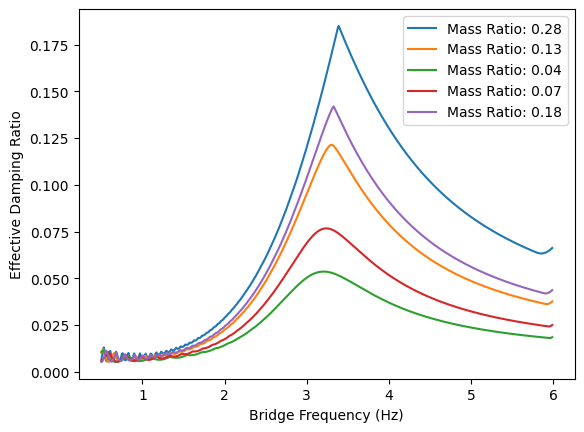

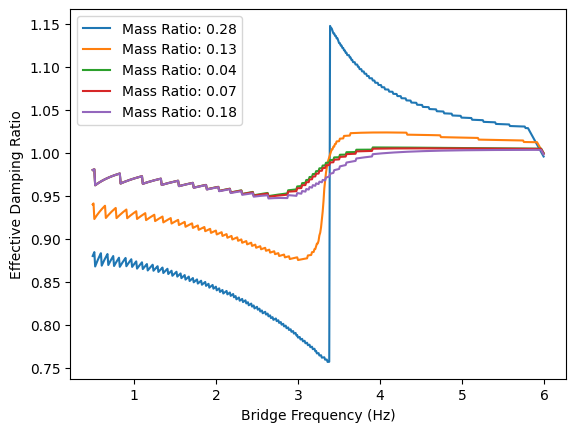

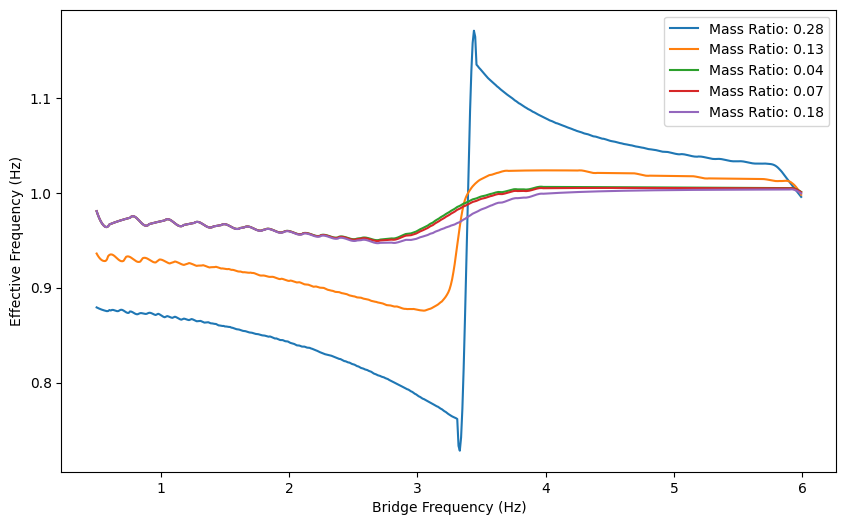

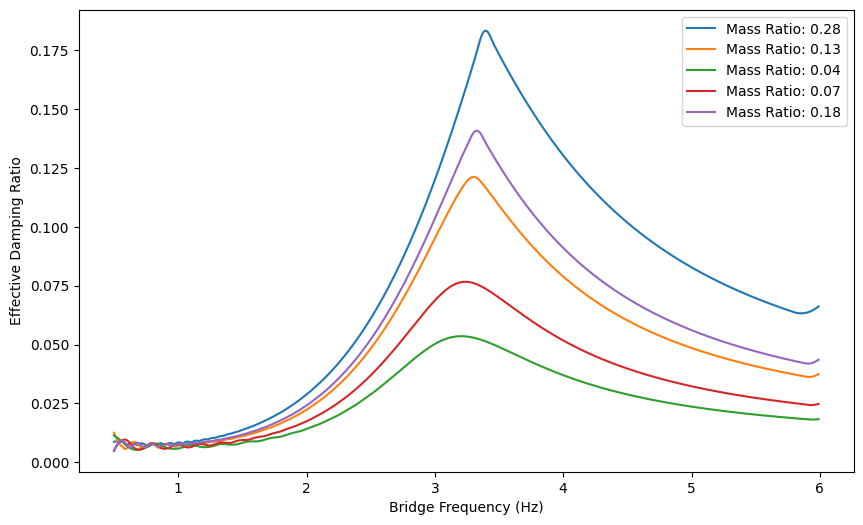

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from pedestrian import Pedestrian
from solver import MatrixAssemblesymetric
from matrix import bridge
from VannimmenHSI import compute_variations
# Setup parameters
length = 10  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 10
pedmass = 73.33     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 3 #Hz
kped1 = (2 * np.pi * pedBodyF)**2 * pedmass
cped1 = (2 * np.pi * pedBodyF) * 2 * peddamp * pedmass

xr = [0]
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)

N_bridge = 2
hht= 1  # Time step

# Initialize pedestrian and bridge parameters
frequency_range = np.arange(0, 6, 0.01)
omega = 2 * np.pi * frequency_range
BridgeFreq = np.arange(0.5, 6, 0.01)

# Prepare arrays to store results 3 is because of the number of mass ratios
damping_variation = np.zeros((5, BridgeFreq.size))
frequency_variation = np.zeros((5, BridgeFreq.size))



# Initial calculation for `max_values0`
xr_initial = np.arange(0, -10, -1)

max_values0,max_frequencies0 = compute_variations(xr_initial,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 1: 19 pedestrians
xr_case1 = np.arange(0.5, 10, 0.5)
modalpedmass_1 = 0 
for i in range(np.size(xr_case1)):
    modalpedmass_1 += pedmass*np.sin(np.pi/length*xr_case1[i])**2
mass_ratio1 = np.size(xr_case1) * pedmass / (linearMass*length)
max_values1,max_frequencies1 = compute_variations(xr_case1,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)


#case 2: 9 pedestrians
xr_case2 = np.arange(1, 10, 1)
modalpedmass_2 = 0 
for i in range(np.size(xr_case2)):
    modalpedmass_2 += pedmass*np.sin(np.pi/length*xr_case2[i])**2
mass_ratio2 = np.size(xr_case2) * pedmass / (linearMass*length)
max_values2,max_frequencies2 = compute_variations(xr_case2,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 3: 3 pedestrians
xr_case3 = np.arange(2.5, 10, 2.5)
modalpedmass_3 = 0 
for i in range(np.size(xr_case3)):
    modalpedmass_3 += pedmass*np.sin(np.pi/length*xr_case3[i])**2
mass_ratio3 = np.size(xr_case3) * pedmass / (linearMass*length)
max_values3,max_frequencies3 = compute_variations(xr_case3,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 5: 12 pedestrians
xr_case5 = np.arange(0.833, 10, 0.833)
modalpedmass_5 = 0 
for i in range(np.size(xr_case5)):
    modalpedmass_5 += pedmass*np.sin(np.pi/length*xr_case5[i])**2
mass_ratio5 = np.size(xr_case5) * pedmass / (linearMass*length)
max_values5,max_frequencies5 = compute_variations(xr_case5,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 4: 6 pedestrians
xr_case4 = np.arange(1.67, 10, 1.67)
modalpedmass_4 = 0 
for i in range(np.size(xr_case4)):
    modalpedmass_4 += pedmass*np.sin(np.pi/length*xr_case4[i])**2
mass_ratio4 = np.size(xr_case4) * pedmass / (linearMass*length)
max_values4,max_frequencies4 = compute_variations(xr_case4,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#calculation of equivalant damping
for i in range(np.size(BridgeFreq)):
    damping_variation[0,i] = (max_values0[i]/max_values1[i])*modalDampingRatio *(linearMass*length)/(linearMass*length+modalpedmass_1)
for i in range(np.size(BridgeFreq)):
    damping_variation[1,i] = max_values0[i]/max_values2[i]*modalDampingRatio*(linearMass*length)/(linearMass*length+modalpedmass_2)
for i in range(np.size(BridgeFreq)):
    damping_variation[2,i] = max_values0[i]/max_values3[i]*modalDampingRatio*(linearMass*length)/(linearMass*length+modalpedmass_3)
for i in range(np.size(BridgeFreq)):
    damping_variation[3,i] = (max_values0[i]/max_values4[i])*modalDampingRatio *(linearMass*length)/(linearMass*length+modalpedmass_4)
for i in range(np.size(BridgeFreq)):
    damping_variation[4,i] = (max_values0[i]/max_values5[i])*modalDampingRatio *(linearMass*length)/(linearMass*length+modalpedmass_5)


frequency_variation[0,:] = max_frequencies1 * np.sqrt(1 - 2 * damping_variation[0,:]**2) / BridgeFreq
frequency_variation[1,:] = max_frequencies2 * np.sqrt(1 - 2 * damping_variation[1,:]**2) / BridgeFreq
frequency_variation[2,:] = max_frequencies3 * np.sqrt(1 - 2 * damping_variation[2,:]**2) / BridgeFreq
frequency_variation[3,:] = max_frequencies3 * np.sqrt(1 - 2 * damping_variation[3,:]**2) / BridgeFreq
frequency_variation[4,:] = max_frequencies3 * np.sqrt(1 - 2 * damping_variation[4,:]**2) / BridgeFreq



plt.plot(BridgeFreq, damping_variation[0], label=f"Mass Ratio: {mass_ratio1:.2f}")
plt.plot(BridgeFreq, damping_variation[1], label=f"Mass Ratio: {mass_ratio2:.2f}")
plt.plot(BridgeFreq, damping_variation[2], label=f"Mass Ratio: {mass_ratio3:.2f}")
plt.plot(BridgeFreq, damping_variation[3], label=f"Mass Ratio: {mass_ratio4:.2f}")
plt.plot(BridgeFreq, damping_variation[4], label=f"Mass Ratio: {mass_ratio5:.2f}")
plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()

plt.plot(BridgeFreq, frequency_variation[0], label=f"Mass Ratio: {mass_ratio1:.2f}")
plt.plot(BridgeFreq, frequency_variation[1], label=f"Mass Ratio: {mass_ratio2:.2f}")
plt.plot(BridgeFreq, frequency_variation[2], label=f"Mass Ratio: {mass_ratio3:.2f}")
plt.plot(BridgeFreq, frequency_variation[3], label=f"Mass Ratio: {mass_ratio4:.2f}")
plt.plot(BridgeFreq, frequency_variation[4], label=f"Mass Ratio: {mass_ratio5:.2f}")
plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()


# Apply smoothing
window_size, poly_order = 15, 2
smoothed_damping_variation = [savgol_filter(damping_variation[i, :], window_size, poly_order) for i in range(5)]
smoothed_frequency_variation = [savgol_filter(frequency_variation[i, :], window_size, poly_order) for i in range(5)]

# Plotting
plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}", f"Mass Ratio: {mass_ratio2:.2f}", f"Mass Ratio: {mass_ratio3:.2f}",f"Mass Ratio: {mass_ratio4:.2f}",f"Mass Ratio: {mass_ratio5:.2f}"]):
    plt.plot(BridgeFreq, smoothed_frequency_variation[i], label=label)

plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Frequency (Hz)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}", f"Mass Ratio: {mass_ratio2:.2f}", f"Mass Ratio: {mass_ratio3:.2f}",f"Mass Ratio: {mass_ratio4:.2f}",f"Mass Ratio: {mass_ratio5:.2f}"]):
    plt.plot(BridgeFreq, smoothed_damping_variation[i], label=label)
plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Damping Ratio")
plt.legend()
plt.show()

In [7]:
import numpy as np
from scipy.signal import savgol_filter
import pickle


# Save the smoothed damping variation lines to disk using pickle
with open("smoothed_damping_variation1.pkl", "wb") as f1:
    pickle.dump(smoothed_damping_variation[0], f1)

with open("smoothed_damping_variation2.pkl", "wb") as f2:
    pickle.dump(smoothed_damping_variation[1], f2)

with open("smoothed_damping_variation3.pkl", "wb") as f3:
    pickle.dump(smoothed_damping_variation[2], f3)

# Save the smoothed damping variation lines to disk using pickle
with open("smoothed_damping_variation_extended.pkl", "wb") as f4:
    pickle.dump(smoothed_damping_variation, f4)

print("Smoothed damping variation lines saved to disk.")

Smoothed damping variation lines saved to disk.


In [15]:
# Save the smoothed damping variation lines to disk using pickle
with open("smoothed_frequency_variation_extended.pkl", "wb") as f5:
    pickle.dump(smoothed_frequency_variation, f5)

print("Smoothed damping variation lines saved to disk.")

Smoothed damping variation lines saved to disk.


In [30]:
for i in range(damping_variation.shape[0]):
    print(f"Last value of row {i} in damping_variation: {damping_variation[i, -1]}")

Last value of row 0 in damping_variation: 0.013972876260391032
Last value of row 1 in damping_variation: 0.00982592596346899
Last value of row 2 in damping_variation: 0.007020601821287523


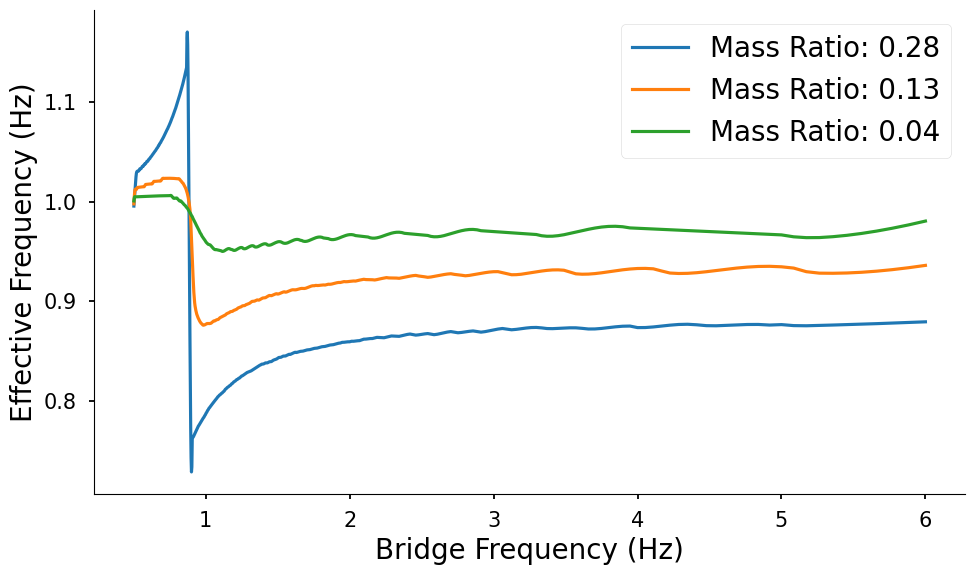

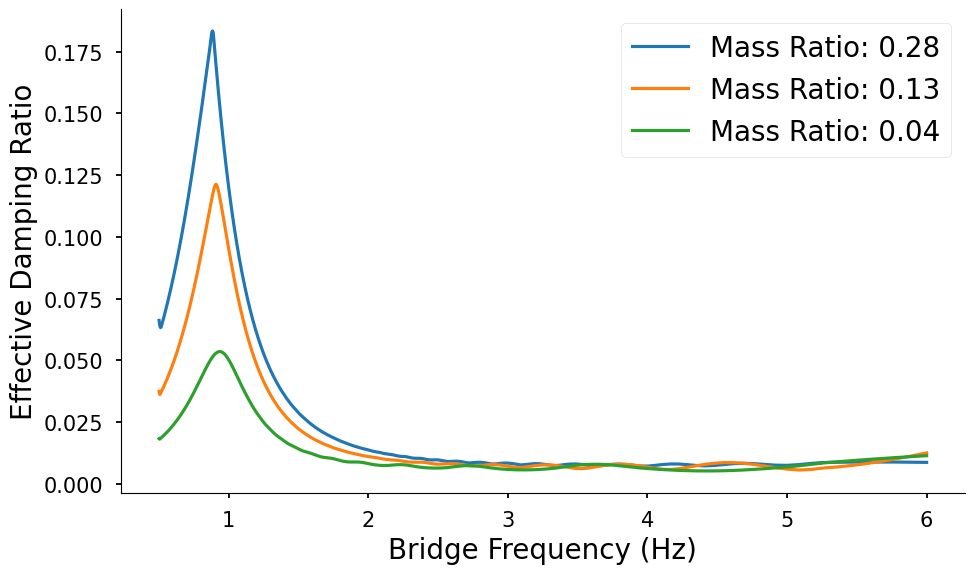

In [2]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 15#10
plt.rcParams['axes.labelsize'] = 20#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 20#8
plt.rcParams['xtick.labelsize'] = 15#8
plt.rcParams['ytick.labelsize'] = 15#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 15#12
rc('text', usetex=False)

# Plotting
plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}", f"Mass Ratio: {mass_ratio2:.2f}", f"Mass Ratio: {mass_ratio3:.2f}"]):
    plt.plot(3/BridgeFreq, smoothed_frequency_variation[i], label=label)

plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Frequency (Hz)")
# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()  # Adjust layout
plt.savefig("effective frequency with mass ratios1.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()

plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}", f"Mass Ratio: {mass_ratio2:.2f}", f"Mass Ratio: {mass_ratio3:.2f}"]):
    plt.plot(3/BridgeFreq, smoothed_damping_variation[i], label=label)
plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Damping Ratio")
# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()  # Adjust layout
plt.savefig("effective damping with mass ratios1.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()

In [17]:
#case 2: 9 pedestrians
xr_case2 = np.arange(1, 10, 1)
pedmass = 83.33     #kg
modalpedmass = 0 
for i in range(np.size(xr_case2)):
    modalpedmass += pedmass*np.sin(np.pi/length*xr_case2[i])**2

print(modalpedmass)

416.65000000000003


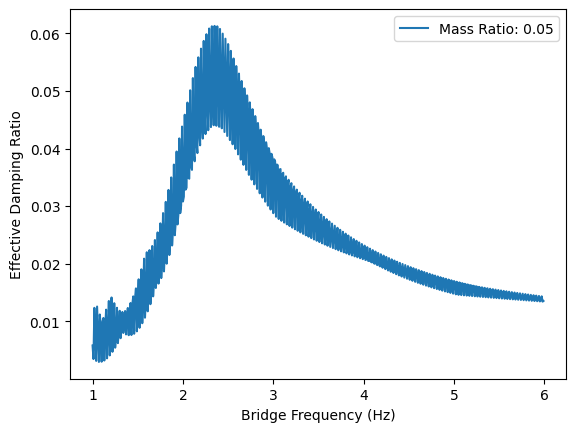

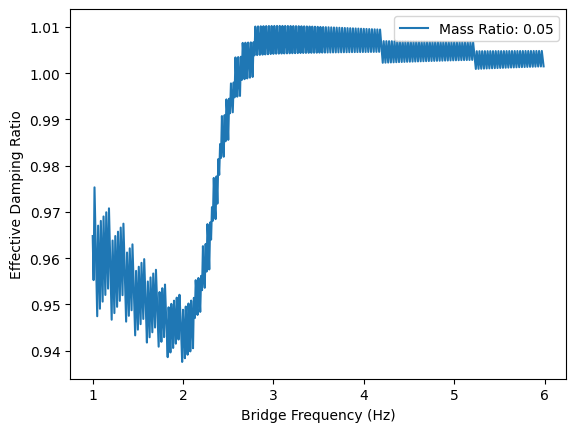

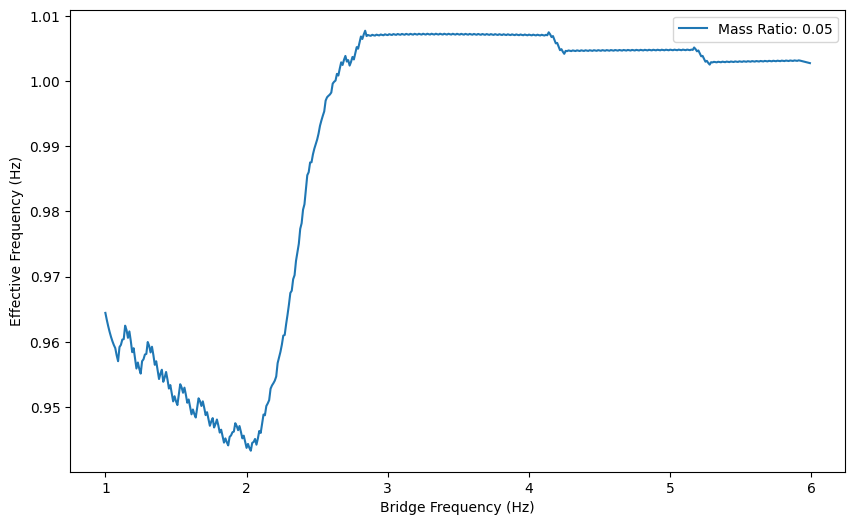

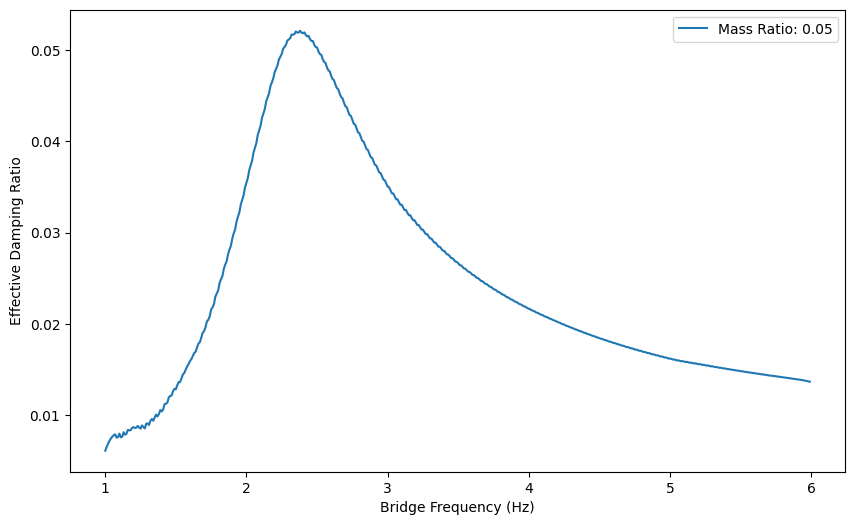

In [5]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from pedestrian import Pedestrian
from solver import MatrixAssemblesymetric
from matrix import bridge
from VannimmenHSI import compute_variations
# Setup parameters
length = 10  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 10
pedmass = 83.33     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2.2 #Hz
kped1 = (2 * np.pi * pedBodyF)**2 * pedmass
cped1 = (2 * np.pi * pedBodyF) * 2 * peddamp * pedmass

xr = [0]
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)

N_bridge = 2
hht= 1  # Time step

# Initialize pedestrian and bridge parameters
frequency_range = np.linspace(0, 6, 200)
omega = 2 * np.pi * frequency_range
BridgeFreq = np.arange(1, 6, 0.01)

# Prepare arrays to store results
damping_variation = np.zeros((1, BridgeFreq.size))
frequency_variation = np.zeros((1, BridgeFreq.size))



# Initial calculation for `max_values0`
xr_initial = np.arange(0, -10, -1)

max_values0,max_frequencies0 = compute_variations(xr_initial,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 1: 19 pedestrians
xr_case1 = np.arange(2.5, 10, 2.5)
mass_ratio1 = np.size(xr_case1) * pedmass / (linearMass*length)
max_values1,max_frequencies1 = compute_variations(xr_case1,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

'''
#case 2: 9 pedestrians
xr_case2 = np.arange(0, 10, 1)
mass_ratio2 = np.size(xr_case2) * pedmass / (linearMass*length)
max_values2,max_frequencies2 = compute_variations(xr_case2,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 3: 4 pedestrians
xr_case3 = np.arange(0, 10, 2)
mass_ratio3 = np.size(xr_case3) * pedmass / (linearMass*length)
max_values3,max_frequencies3 = compute_variations(xr_case3,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

'''
#calculation of equivalant damping
for i in range(np.size(BridgeFreq)):
    damping_variation[0,i] = max_values0[i]/max_values1[i]*modalDampingRatio
#for i in range(np.size(BridgeFreq)):
#    damping_variation[1,i] = max_values0[i]/max_values2[i]*modalDampingRatio
#for i in range(np.size(BridgeFreq)):
 #   damping_variation[2,i] = max_values0[i]/max_values3[i]*modalDampingRatio

frequency_variation[0,:] = max_frequencies1 * np.sqrt(1 - 2 * damping_variation[0,:]**2) / BridgeFreq
#frequency_variation[1,:] = max_frequencies2 * np.sqrt(1 - 2 * damping_variation[1,:]**2) / BridgeFreq
#frequency_variation[2,:] = max_frequencies3 * np.sqrt(1 - 2 * damping_variation[2,:]**2) / BridgeFreq



plt.plot(BridgeFreq, damping_variation[0], label=f"Mass Ratio: {mass_ratio1:.2f}")
#plt.plot(BridgeFreq, damping_variation[1], label=f"Mass Ratio: {mass_ratio2:.2f}")
#plt.plot(BridgeFreq, damping_variation[2], label=f"Mass Ratio: {mass_ratio3:.2f}")
plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()

plt.plot(BridgeFreq, frequency_variation[0], label=f"Mass Ratio: {mass_ratio1:.2f}")
#plt.plot(BridgeFreq, frequency_variation[1], label=f"Mass Ratio: {mass_ratio2:.2f}")
#plt.plot(BridgeFreq, frequency_variation[2], label=f"Mass Ratio: {mass_ratio3:.2f}")
plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()


# Apply smoothing
window_size, poly_order = 15, 2
smoothed_damping_variation = [savgol_filter(damping_variation[0, :], window_size, poly_order)]
smoothed_frequency_variation = [savgol_filter(frequency_variation[0, :], window_size, poly_order)]

# Plotting
plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}"]):
    plt.plot(BridgeFreq, smoothed_frequency_variation[i], label=label)

plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Frequency (Hz)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}"]):
    plt.plot(BridgeFreq, smoothed_damping_variation[i], label=label)
plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Damping Ratio")
plt.legend()
plt.show()

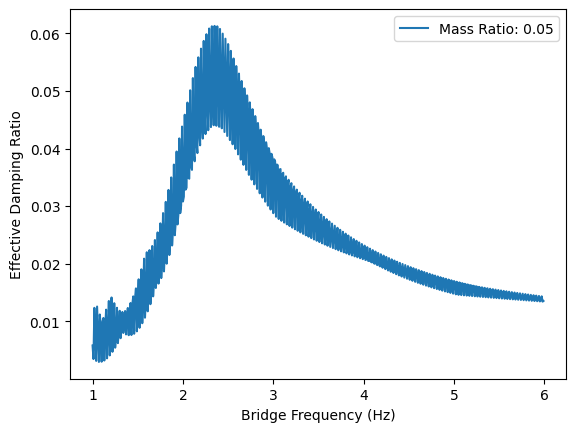

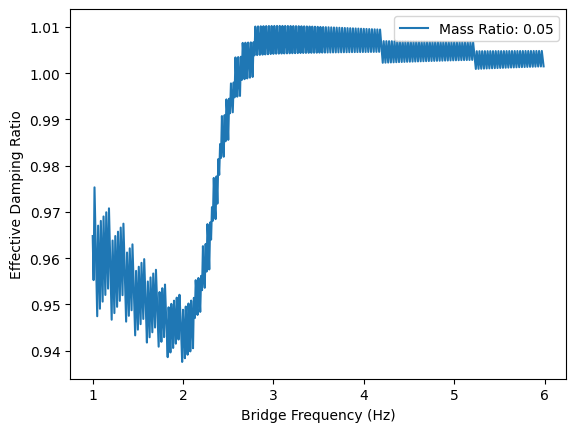

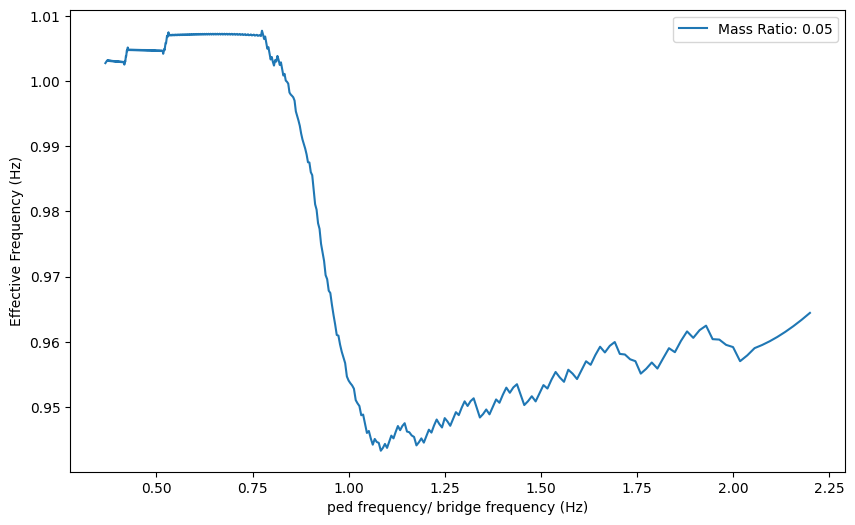

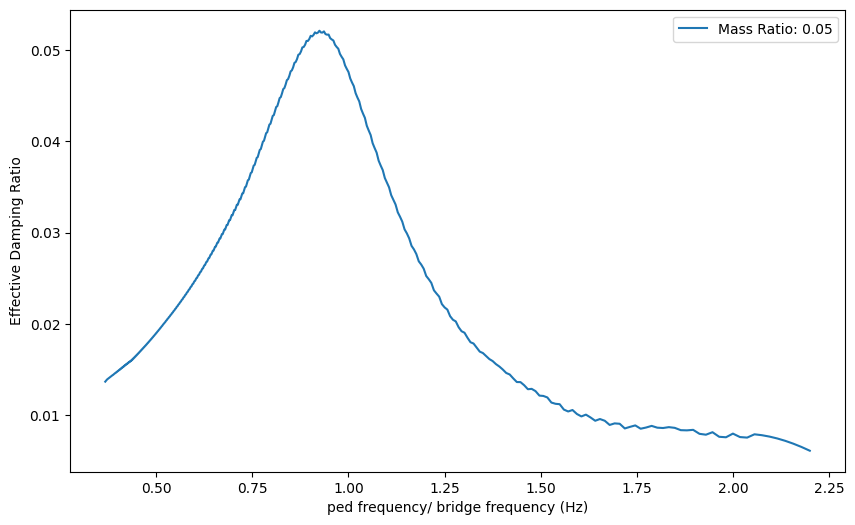

In [12]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from pedestrian import Pedestrian
from solver import MatrixAssemblesymetric
from matrix import bridge
from VannimmenHSI import compute_variations
# Setup parameters
length = 10  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 10
pedmass = 83.33     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2.2 #Hz
kped1 = (2 * np.pi * pedBodyF)**2 * pedmass
cped1 = (2 * np.pi * pedBodyF) * 2 * peddamp * pedmass

xr = [0]
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)

N_bridge = 2
hht= 1  # Time step

# Initialize pedestrian and bridge parameters
frequency_range = np.linspace(0, 6, 200)
omega = 2 * np.pi * frequency_range
BridgeFreq = np.arange(1, 6, 0.01)

# Prepare arrays to store results
damping_variation = np.zeros((1, BridgeFreq.size))
frequency_variation = np.zeros((1, BridgeFreq.size))



# Initial calculation for `max_values0`
xr_initial = np.arange(0, -10, -1)

max_values0,max_frequencies0 = compute_variations(xr_initial,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 1: 19 pedestrians
xr_case1 = np.arange(2.5, 10, 2.5)
mass_ratio1 = np.size(xr_case1) * pedmass / (linearMass*length)
max_values1,max_frequencies1 = compute_variations(xr_case1,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

'''
#case 2: 9 pedestrians
xr_case2 = np.arange(0, 10, 1)
mass_ratio2 = np.size(xr_case2) * pedmass / (linearMass*length)
max_values2,max_frequencies2 = compute_variations(xr_case2,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 3: 4 pedestrians
xr_case3 = np.arange(0, 10, 2)
mass_ratio3 = np.size(xr_case3) * pedmass / (linearMass*length)
max_values3,max_frequencies3 = compute_variations(xr_case3,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

'''
#calculation of equivalant damping
for i in range(np.size(BridgeFreq)):
    damping_variation[0,i] = max_values0[i]/max_values1[i]*modalDampingRatio
#for i in range(np.size(BridgeFreq)):
#    damping_variation[1,i] = max_values0[i]/max_values2[i]*modalDampingRatio
#for i in range(np.size(BridgeFreq)):
 #   damping_variation[2,i] = max_values0[i]/max_values3[i]*modalDampingRatio

frequency_variation[0,:] = max_frequencies1 * np.sqrt(1 - 2 * damping_variation[0,:]**2) / BridgeFreq
#frequency_variation[1,:] = max_frequencies2 * np.sqrt(1 - 2 * damping_variation[1,:]**2) / BridgeFreq
#frequency_variation[2,:] = max_frequencies3 * np.sqrt(1 - 2 * damping_variation[2,:]**2) / BridgeFreq



plt.plot(BridgeFreq, damping_variation[0], label=f"Mass Ratio: {mass_ratio1:.2f}")
#plt.plot(BridgeFreq, damping_variation[1], label=f"Mass Ratio: {mass_ratio2:.2f}")
#plt.plot(BridgeFreq, damping_variation[2], label=f"Mass Ratio: {mass_ratio3:.2f}")
plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()

plt.plot(BridgeFreq, frequency_variation[0], label=f"Mass Ratio: {mass_ratio1:.2f}")
#plt.plot(BridgeFreq, frequency_variation[1], label=f"Mass Ratio: {mass_ratio2:.2f}")
#plt.plot(BridgeFreq, frequency_variation[2], label=f"Mass Ratio: {mass_ratio3:.2f}")
plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()


# Apply smoothing
window_size, poly_order = 15, 2
smoothed_damping_variation = [savgol_filter(damping_variation[0, :], window_size, poly_order)]
smoothed_frequency_variation = [savgol_filter(frequency_variation[0, :], window_size, poly_order)]

# Plotting
plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}"]):
    plt.plot(2.2/BridgeFreq, smoothed_frequency_variation[i], label=label)

plt.xlabel("ped frequency/ bridge frequency (Hz)")
plt.ylabel("Effective Frequency (Hz)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio1:.2f}"]):
    plt.plot(2.2/BridgeFreq, smoothed_damping_variation[i], label=label)
plt.xlabel("ped frequency/ bridge frequency (Hz)")
plt.ylabel("Effective Damping Ratio")
plt.legend()
plt.show()

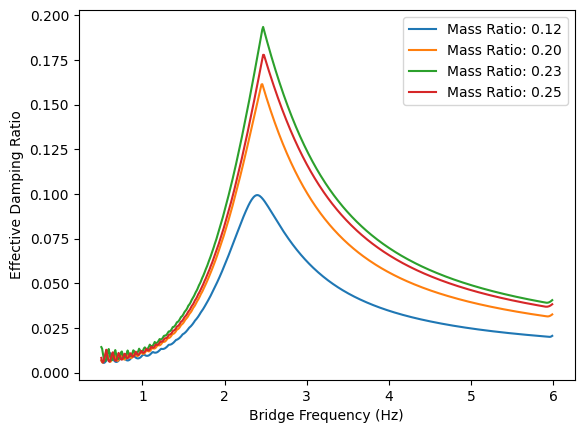

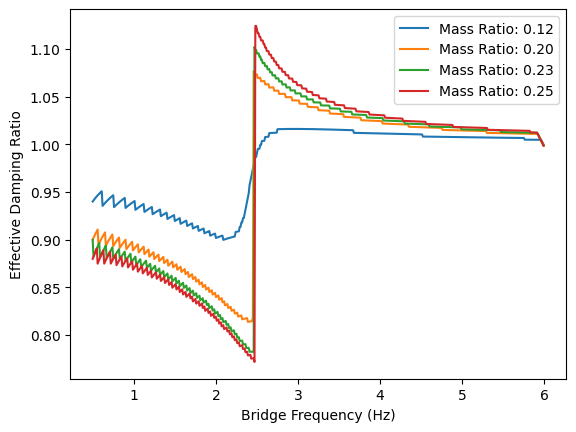

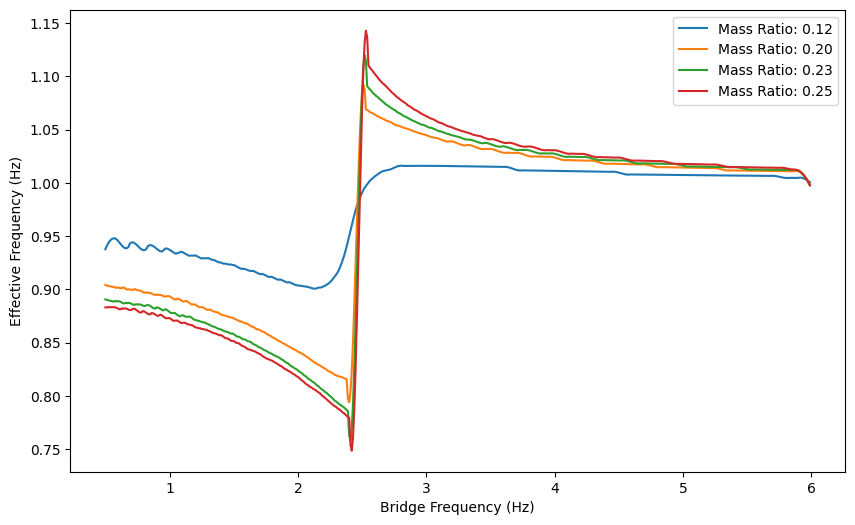

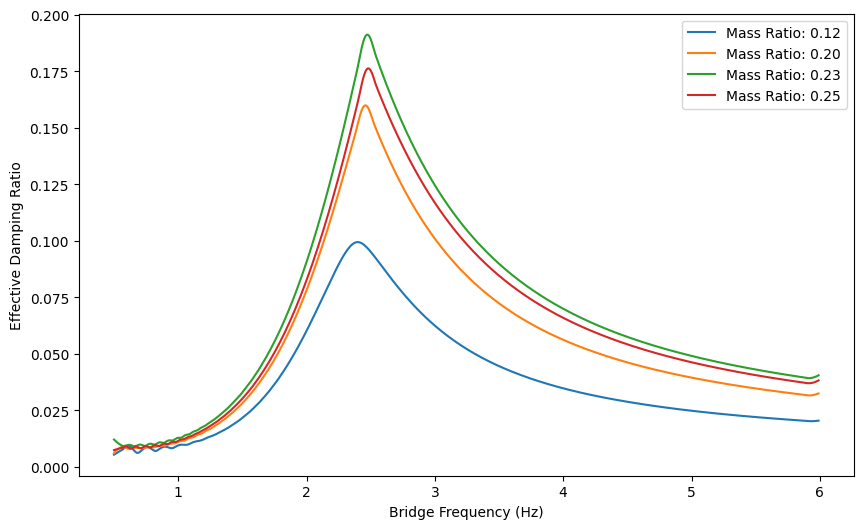

In [16]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from pedestrian import Pedestrian
from solver import MatrixAssemblesymetric
from matrix import bridge
from VannimmenHSI import compute_variations
# Setup parameters
length = 10  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 10
pedmass = 83.33     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2.2 #Hz
kped1 = (2 * np.pi * pedBodyF)**2 * pedmass
cped1 = (2 * np.pi * pedBodyF) * 2 * peddamp * pedmass

xr = [0]
numped = np.size(xr)  
mped = np.repeat(pedmass,numped)  #np.array([pedmass])
cped = np.repeat(cped1,numped)    #np.array([cped1])
kped = np.repeat(kped1,numped)

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)

N_bridge = 2
hht= 1  # Time step

# Initialize pedestrian and bridge parameters
frequency_range = np.arange(0, 6, 0.01)
omega = 2 * np.pi * frequency_range
BridgeFreq = np.arange(0.5, 6, 0.01)

# Prepare arrays to store results 3 is because of the number of mass ratios
damping_variation = np.zeros((4, BridgeFreq.size))
frequency_variation = np.zeros((4, BridgeFreq.size))



# Initial calculation for `max_values0`
xr_initial = np.arange(0, -10, -1)

max_values0,max_frequencies0 = compute_variations(xr_initial,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 6: 7 pedestrians
xr_case6 = np.arange(1.42, 10, 1.42)
modalpedmass_6 = 0 
for i in range(np.size(xr_case6)):
    modalpedmass_6 += pedmass*np.sin(np.pi/length*xr_case6[i])**2
mass_ratio6 = np.size(xr_case6) * pedmass / (linearMass*length)
max_values6,max_frequencies6 = compute_variations(xr_case6,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)


#case 7: 13 pedestrians
xr_case7 = np.arange(0.77, 10, 0.77)
modalpedmass_7 = 0 
for i in range(np.size(xr_case7)):
    modalpedmass_7 += pedmass*np.sin(np.pi/length*xr_case7[i])**2
mass_ratio7 = np.size(xr_case7) * pedmass / (linearMass*length)
max_values7,max_frequencies7 = compute_variations(xr_case7,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 8: 15 pedestrians
xr_case8 = np.arange(0.667, 10, 0.667)
modalpedmass_8 = 0 
for i in range(np.size(xr_case3)):
    modalpedmass_8 += pedmass*np.sin(np.pi/length*xr_case8[i])**2
mass_ratio8 = np.size(xr_case8) * pedmass / (linearMass*length)
max_values8,max_frequencies8 = compute_variations(xr_case8,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)

#case 9: 16 pedestrians
xr_case9 = np.arange(0.625, 10, 0.625)
modalpedmass_9 = 0 
for i in range(np.size(xr_case9)):
    modalpedmass_9 += pedmass*np.sin(np.pi/length*xr_case9[i])**2
mass_ratio9 = np.size(xr_case9) * pedmass / (linearMass*length)
max_values9,max_frequencies9 = compute_variations(xr_case9,BridgeFreq,frequency_range,omega,pedmass,cped1,kped1,linearMass,length,modalDampingRatio,numbers,Human)


#calculation of equivalant damping
for i in range(np.size(BridgeFreq)):
    damping_variation[0,i] = (max_values0[i]/max_values6[i])*modalDampingRatio *(linearMass*length)/(linearMass*length+modalpedmass_6)
for i in range(np.size(BridgeFreq)):
    damping_variation[1,i] = max_values0[i]/max_values7[i]*modalDampingRatio*(linearMass*length)/(linearMass*length+modalpedmass_7)
for i in range(np.size(BridgeFreq)):
    damping_variation[2,i] = max_values0[i]/max_values8[i]*modalDampingRatio*(linearMass*length)/(linearMass*length+modalpedmass_8)
for i in range(np.size(BridgeFreq)):
    damping_variation[3,i] = (max_values0[i]/max_values9[i])*modalDampingRatio *(linearMass*length)/(linearMass*length+modalpedmass_9)



frequency_variation[0,:] = max_frequencies6 * np.sqrt(1 - 2 * damping_variation[0,:]**2) / BridgeFreq
frequency_variation[1,:] = max_frequencies7 * np.sqrt(1 - 2 * damping_variation[1,:]**2) / BridgeFreq
frequency_variation[2,:] = max_frequencies8 * np.sqrt(1 - 2 * damping_variation[2,:]**2) / BridgeFreq
frequency_variation[3,:] = max_frequencies9 * np.sqrt(1 - 2 * damping_variation[3,:]**2) / BridgeFreq




plt.plot(BridgeFreq, damping_variation[0], label=f"Mass Ratio: {mass_ratio6:.2f}")
plt.plot(BridgeFreq, damping_variation[1], label=f"Mass Ratio: {mass_ratio7:.2f}")
plt.plot(BridgeFreq, damping_variation[2], label=f"Mass Ratio: {mass_ratio8:.2f}")
plt.plot(BridgeFreq, damping_variation[3], label=f"Mass Ratio: {mass_ratio9:.2f}")

plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()

plt.plot(BridgeFreq, frequency_variation[0], label=f"Mass Ratio: {mass_ratio6:.2f}")
plt.plot(BridgeFreq, frequency_variation[1], label=f"Mass Ratio: {mass_ratio7:.2f}")
plt.plot(BridgeFreq, frequency_variation[2], label=f"Mass Ratio: {mass_ratio8:.2f}")
plt.plot(BridgeFreq, frequency_variation[3], label=f"Mass Ratio: {mass_ratio9:.2f}")

plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.show()


# Apply smoothing
window_size, poly_order = 15, 2
smoothed_damping_variation = [savgol_filter(damping_variation[i, :], window_size, poly_order) for i in range(4)]
smoothed_frequency_variation = [savgol_filter(frequency_variation[i, :], window_size, poly_order) for i in range(4)]

# Plotting
plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio6:.2f}", f"Mass Ratio: {mass_ratio7:.2f}", f"Mass Ratio: {mass_ratio8:.2f}",f"Mass Ratio: {mass_ratio9:.2f}"]):
    plt.plot(BridgeFreq, smoothed_frequency_variation[i], label=label)

plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Frequency (Hz)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i, label in enumerate([f"Mass Ratio: {mass_ratio6:.2f}", f"Mass Ratio: {mass_ratio7:.2f}", f"Mass Ratio: {mass_ratio8:.2f}",f"Mass Ratio: {mass_ratio9:.2f}"]):
    plt.plot(BridgeFreq, smoothed_damping_variation[i], label=label)
plt.xlabel("Bridge Frequency (Hz)")
plt.ylabel("Effective Damping Ratio")
plt.legend()
plt.show()

In [10]:
import numpy as np
from scipy.signal import savgol_filter
import pickle



# Save the smoothed damping variation lines to disk using pickle
with open("smoothed_damping_variation_extended2.pkl", "wb") as f4:
    pickle.dump(smoothed_damping_variation, f4)

print("Smoothed damping variation lines saved to disk.")

Smoothed damping variation lines saved to disk.


In [17]:
# Save the smoothed damping variation lines to disk using pickle
with open("smoothed_frequency_variation_extended2.pkl", "wb") as f10:
    pickle.dump(smoothed_frequency_variation, f10)

print("Smoothed damping variation lines saved to disk.")

Smoothed damping variation lines saved to disk.
